## Classification for Time Series
### Variable target: rating_category
#### K-NN with features extraction and Euclidean distance

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [17]:
ts_imdb = pd.read_csv('TS_NO_OUTLIERS.csv').drop(columns=['id'])

ts_imdb.head()

,0,1,2,3,4,5,6,7,8,9,...,genre_Music,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Short,genre_Sport,genre_Thriller,genre_War,genre_Western
0,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,32571.0,...,0,0,0,0,1,0,0,0,0,0
1,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,1449.0,...,0,0,0,1,0,0,0,0,0,0
2,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,119608.0,...,1,0,0,0,0,0,0,0,0,0
3,682857.0,407032.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,7697.0,...,0,0,0,0,1,0,0,0,0,0
4,7813372.0,6274563.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,3108057.0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# Analisi preliminare del target
print("Distribuzione delle classi nel target 'rating_category':")
print(ts_imdb['rating_category'].value_counts())
print(f"\nNumero di classi uniche: {ts_imdb['rating_category'].nunique()}")


# split train e test
X_train, X_test, y_train, y_test = train_test_split(
    ts_imdb, ts_imdb['rating_category'], test_size=0.2, random_state=42
)

Distribuzione delle classi nel target 'rating_category':
rating_category
2    387
4    361
3    226
1    128
0     10
Name: count, dtype: int64

Numero di classi uniche: 5


In [19]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((889, 124), (223, 124), (889,), (223,))

In [20]:
y_train.value_counts(), y_test.value_counts()

(rating_category
 2    303
 4    298
 3    177
 1    103
 0      8
 Name: count, dtype: int64,
 rating_category
 2    84
 4    63
 3    49
 1    25
 0     2
 Name: count, dtype: int64)

In [21]:
# create a list of columns that has a number in their name
columns_with_numbers = [col for col in X_train.columns if any(char.isdigit() for char in col)]

print("Columns with numbers in their names:")
print(columns_with_numbers)

Columns with numbers in their names:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']


In [22]:
import scipy.stats as stats
from scipy.signal import find_peaks

import numpy as np

def calculate_average_peak_distance(timeseries, prominence=0.2, distance=1):
    """
    Calcola la distanza media tra picchi locali in una serie temporale.
    """
    peaks, _ = find_peaks(timeseries, prominence=prominence, distance=distance)
    if len(peaks) < 2:
        return np.nan  # Restituisci NaN se ci sono meno di 2 picchi
    return np.mean(np.diff(peaks))

def calculate_mean_change(timeseries):
    """
    Calcola la variazione media tra valori consecutivi in una serie temporale.

    Parameters:
    - timeseries: array-like, serie temporale.

    Returns:
    - mean_change: float, variazione media.
    """
    differences = np.abs(np.diff(timeseries))  # Differenze assolute tra valori consecutivi
    mean_change = np.mean(differences)        # Media delle differenze
    return mean_change

def calculate_autocorrelation(timeseries, lag=1):
    """
    Calcola l'autocorrelazione della serie temporale a un lag specificato.

    Parameters:
    - timeseries: array-like, serie temporale.
    - lag: int, ritardo per il calcolo dell'autocorrelazione.

    Returns:
    - autocorrelation: float, valore dell'autocorrelazione.
    """
    return pd.Series(timeseries).autocorr(lag=lag)

def calculate_features(values):
    features = {
        'avg': np.mean(values),
        'std': np.std(values),
        'var': np.var(values),
        'med': np.median(values),
        '10p': np.percentile(values, 10),
        '25p': np.percentile(values, 25),
        '50p': np.percentile(values, 50),
        '75p': np.percentile(values, 75),
        '90p': np.percentile(values, 90),
        'iqr': np.percentile(values, 75) - np.percentile(values, 25),
        'cov': 1.0 * np.mean(values) / np.std(values),
        'skw': stats.skew(values),
        'kur': stats.kurtosis(values),
        'range': np.max(values) - np.min(values),
        'mad': np.mean(np.abs(values - np.mean(values))),
        'num_peaks': len(find_peaks(values)[0]),
        'slope': np.polyfit(np.arange(len(values)), values, 1)[0],
        'average_peak_distance': calculate_average_peak_distance(values),
        'mean_change': calculate_mean_change(values),
        'autocorrelation_1': calculate_autocorrelation(values, lag=1),
        'autocorrelation_2': calculate_autocorrelation(values, lag=2),
        'autocorrelation_3': calculate_autocorrelation(values, lag=3),
        'autocorrelation_7': calculate_autocorrelation(values, lag=7),
        'autocorrelation_11': calculate_autocorrelation(values, lag=11),
        'autocorrelation_14': calculate_autocorrelation(values, lag=14),
        'autocorrelation_17': calculate_autocorrelation(values, lag=17),
        'min': np.min(values),
        'max': np.max(values),
        'sum': np.sum(values)
    }

    return features

In [23]:
X_train_numbers = X_train[columns_with_numbers]
feature_values = [list(calculate_features(row).values()) for row in X_train_numbers.values]
index_values = list(range(0, X_train_numbers.shape[0]))

# Correzione: usa la prima riga invece di un singolo valore
column_values = list(calculate_features(X_train_numbers.iloc[0].values).keys())

CF_Train = pd.DataFrame(data=feature_values, index=index_values, columns=column_values) 
CF_Train['rating_category'] = X_train['rating_category'].values

CF_Train

,avg,std,var,med,10p,25p,50p,75p,90p,iqr,...,autocorrelation_2,autocorrelation_3,autocorrelation_7,autocorrelation_11,autocorrelation_14,autocorrelation_17,min,max,sum,rating_category
0,253954.00,3.467162e+05,1.202121e+11,83476.0,8172.3,19159.25,83476.0,358115.00,716820.2,338955.75,...,0.827172,0.701542,0.351972,0.289029,0.300506,0.263035,3349.0,1410628.0,25395400.0,1
1,84956.80,1.054765e+05,1.112530e+10,35312.5,8492.0,18425.50,35312.5,109600.50,224761.0,91175.00,...,0.797484,0.662310,0.402974,0.322984,0.420391,0.377192,5580.0,471508.0,8495680.0,4
2,207760.65,2.147551e+05,4.611974e+10,124199.5,36808.1,69588.50,124199.5,305319.75,382996.1,235731.25,...,0.920291,0.855349,0.651065,0.609270,0.765230,0.754375,26094.0,1195749.0,20776065.0,3
3,265244.19,4.857409e+05,2.359443e+11,37175.0,4740.7,8610.50,37175.0,273261.25,823159.9,264650.75,...,0.956215,0.914552,0.785992,0.797385,0.967915,0.958320,2757.0,2479596.0,26524419.0,2
4,96534.46,7.877690e+04,6.205799e+09,72075.5,20176.3,34091.50,72075.5,130576.25,227356.5,96484.75,...,0.704115,0.459368,-0.059883,0.185532,0.733556,0.352819,4465.0,331740.0,9653446.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,179187.86,2.821824e+05,7.962692e+10,38572.0,4089.2,8358.00,38572.0,241301.00,493669.6,232943.00,...,0.938549,0.902403,0.873433,0.848622,0.973183,0.909938,2972.0,1318743.0,17918786.0,2
885,169972.30,2.016880e+05,4.067806e+10,98590.0,13818.4,35541.75,98590.0,202026.00,458635.0,166484.25,...,0.728409,0.503100,0.093129,0.167957,0.483499,0.331560,9132.0,920010.0,16997230.0,3
886,59677.74,3.779569e+04,1.428514e+09,52984.5,17631.4,24215.50,52984.5,83339.75,107262.4,59124.25,...,0.714466,0.508544,0.029390,0.149836,0.563142,0.211404,10409.0,165093.0,5967774.0,4
887,1387445.47,1.983573e+06,3.934561e+12,602185.0,112692.1,216119.25,602185.0,1610781.25,3271667.8,1394662.00,...,0.871736,0.767157,0.386302,0.504293,0.890180,0.774228,44742.0,10005790.0,138744547.0,2


In [24]:
X_test_numbers = X_test[columns_with_numbers]
feature_values_test = [list(calculate_features(row).values()) for row in X_test_numbers.values]
index_values_test = list(range(0, X_test_numbers.shape[0]))

CF_Test = pd.DataFrame(data=feature_values_test, index=index_values_test, columns=column_values)
CF_Test['rating_category'] = X_test['rating_category'].values

CF_Test

,avg,std,var,med,10p,25p,50p,75p,90p,iqr,...,autocorrelation_2,autocorrelation_3,autocorrelation_7,autocorrelation_11,autocorrelation_14,autocorrelation_17,min,max,sum,rating_category
0,1278937.85,1.764151e+06,3.112230e+12,581357.0,33033.4,85998.25,581357.0,1701821.25,3294076.4,1615823.00,...,0.930662,0.932109,0.867681,0.858266,0.901383,0.945160,14297.0,9306397.0,127893785.0,2
1,9375742.78,1.372164e+07,1.882835e+14,3801105.0,696081.9,1943784.00,3801105.0,10624954.00,24095107.0,8681170.00,...,0.879038,0.764599,0.413463,0.598046,0.975926,0.765914,467892.0,63777443.0,937574278.0,4
2,40060.70,2.820969e+04,7.957865e+08,35086.0,12787.9,17394.50,35086.0,54187.25,72328.4,36792.75,...,0.656820,0.360167,-0.330245,0.045895,0.720807,0.332292,7339.0,128889.0,4006070.0,4
3,81517.14,1.389997e+05,1.932090e+10,17711.5,1762.9,4135.50,17711.5,92422.25,226701.4,88286.75,...,0.867588,0.774572,0.628898,0.679940,0.961169,0.848643,1098.0,700041.0,8151714.0,3
4,66305.27,6.670979e+04,4.450196e+09,49294.0,11668.3,21088.25,49294.0,82615.25,154519.7,61527.00,...,0.705767,0.466345,0.051280,0.191712,0.619934,0.302024,5364.0,340543.0,6630527.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,743024.38,1.163885e+06,1.354627e+12,185243.0,26367.5,41388.50,185243.0,1024660.75,1915446.6,983272.25,...,0.948221,0.902019,0.787894,0.802464,0.972112,0.887494,9287.0,5670011.0,74302438.0,1
219,643175.77,1.086972e+06,1.181509e+12,187130.5,8406.9,28773.75,187130.5,717241.25,1586489.3,688467.50,...,0.875511,0.782287,0.525531,0.649409,0.984515,0.762507,5190.0,5564285.0,64317577.0,1
220,316452.70,4.382185e+05,1.920354e+11,141618.0,6313.8,24623.00,141618.0,421704.25,843191.5,397081.25,...,0.875743,0.781177,0.669732,0.677717,0.979053,0.800656,1880.0,2059715.0,31645270.0,3
221,426852.08,6.818018e+05,4.648537e+11,112601.0,12314.1,32034.25,112601.0,554227.50,1105631.8,522193.25,...,0.898100,0.808065,0.556630,0.625822,0.953156,0.787914,5368.0,3165789.0,42685208.0,1


In [25]:
# normalization 
from sklearn.preprocessing import StandardScaler

X_train_feat = CF_Train.drop(columns='rating_category')
y_train = CF_Train['rating_category']

X_test_feat = CF_Test.drop(columns='rating_category')
y_test = CF_Test['rating_category']

# 2. Z-score normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)

# 3. Ricostruzione dei DataFrame normalizzati
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_feat.columns, index=X_train_feat.index)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_feat.columns, index=X_test_feat.index)

X_train_scaled.head()


,avg,std,var,med,10p,25p,50p,75p,90p,iqr,...,autocorrelation_1,autocorrelation_2,autocorrelation_3,autocorrelation_7,autocorrelation_11,autocorrelation_14,autocorrelation_17,min,max,sum
0,-0.650684,-0.623876,-0.347282,-0.659308,-0.563450,-0.608302,-0.659308,-0.624592,-0.631133,-0.607152,...,-0.375233,-0.319679,-0.241420,-0.293274,-1.219999,-2.968505,-1.878953,-0.509998,-0.610277,-0.650684
1,-0.757512,-0.730625,-0.351975,-0.720507,-0.562024,-0.610215,-0.720507,-0.757423,-0.757243,-0.768002,...,-0.850108,-0.676732,-0.514771,-0.109111,-1.064930,-2.323573,-1.352575,-0.492503,-0.687230,-0.757512
2,-0.679884,-0.682269,-0.350469,-0.607563,-0.435730,-0.476798,-0.607563,-0.652811,-0.716689,-0.674161,...,0.777839,0.800252,0.830258,0.786720,0.242527,-0.468469,0.386622,-0.331638,-0.627884,-0.679884
3,-0.643547,-0.562357,-0.342303,-0.718141,-0.578755,-0.635810,-0.718141,-0.669946,-0.603880,-0.655388,...,1.167975,1.232308,1.242760,1.273926,1.101641,0.621897,1.327011,-0.514640,-0.522683,-0.643547
4,-0.750193,-0.742440,-0.352186,-0.673794,-0.509910,-0.569363,-0.673794,-0.746211,-0.756578,-0.764555,...,-1.673315,-1.799668,-1.928797,-1.780438,-1.692665,-0.638864,-1.464961,-0.501247,-0.698683,-0.750193


In [26]:
# tuning of KNN with randomized search
from scipy.stats import randint

knn = KNeighborsClassifier()

param_dist = {
    'n_neighbors': randint(1, 20),
    'weights': ['uniform', 'distance'], # 'uniform' for equal weight, 'distance' for weight by distance
    'metric': ['euclidean']
}

random_search = RandomizedSearchCV(
    knn,
    param_distributions=param_dist,
    n_iter=50,                    # numero di combinazioni da provare
    cv=5,                         # 5-fold cross-validation
    scoring='f1_macro',  # utilizza la media F1 macro come metrica di valutazione
    random_state=42,
    n_jobs=-1                     # usa tutti i core disponibili
)

random_search.fit(X_train_scaled, y_train)


RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(), n_iter=50, n_jobs=-1,
                   param_distributions={'metric': ['euclidean'],
                                        'n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002B0437B8530>,
                                        'weights': ['uniform', 'distance']},
                   random_state=42, scoring='f1_macro')

In [27]:
print("Best parameters:", random_search.best_params_)

# Evaluation on the test set
best_knn = random_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Best parameters: {'metric': 'euclidean', 'n_neighbors': 12, 'weights': 'uniform'}
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.20      0.12      0.15        25
           2       0.52      0.64      0.58        84
           3       0.38      0.16      0.23        49
           4       0.51      0.68      0.59        63

    accuracy                           0.48       223
   macro avg       0.32      0.32      0.31       223
weighted avg       0.45      0.48      0.45       223



c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

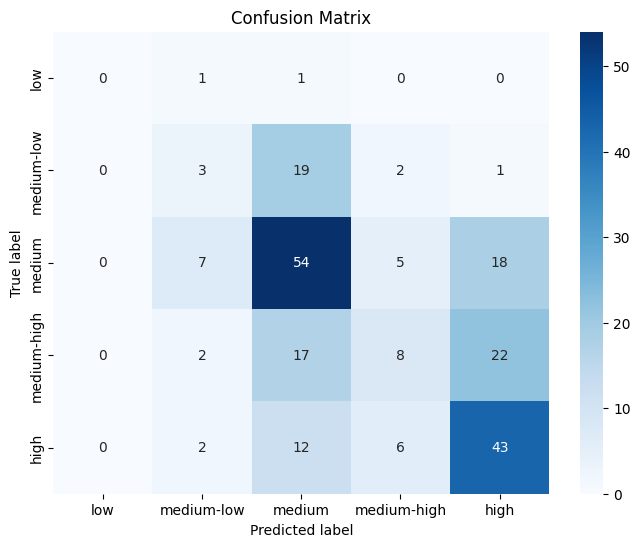

In [28]:
# Confusion matrix visualization
import seaborn as sns

# target names
class_names = ['low', 'medium-low', 'medium', 'medium-high', 'high']

# Calcola la confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


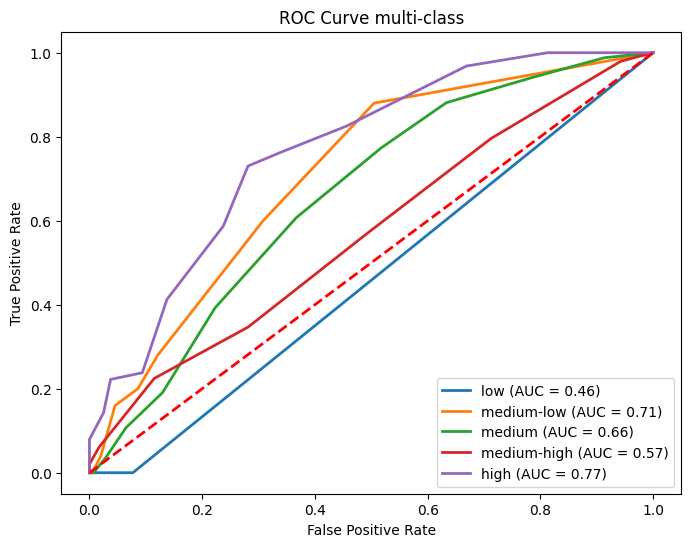

In [29]:
# Roc Curve and AUC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Definisci le classi e i loro nomi
classes = [0, 1, 2, 3, 4]
class_names = ['low', 'medium-low', 'medium', 'medium-high', 'high']

# Binarizza le etichette di test per multi-classe (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=classes)

# Probabilità predette dal modello KNN (probabilità per ogni classe)
y_score = best_knn.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label='{} (AUC = {:.2f})'.format(class_names[i], roc_auc))

plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')  # Linea di non discriminazione
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve multi-class')
plt.legend(loc='lower right')
plt.show()


c:\Users\curia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


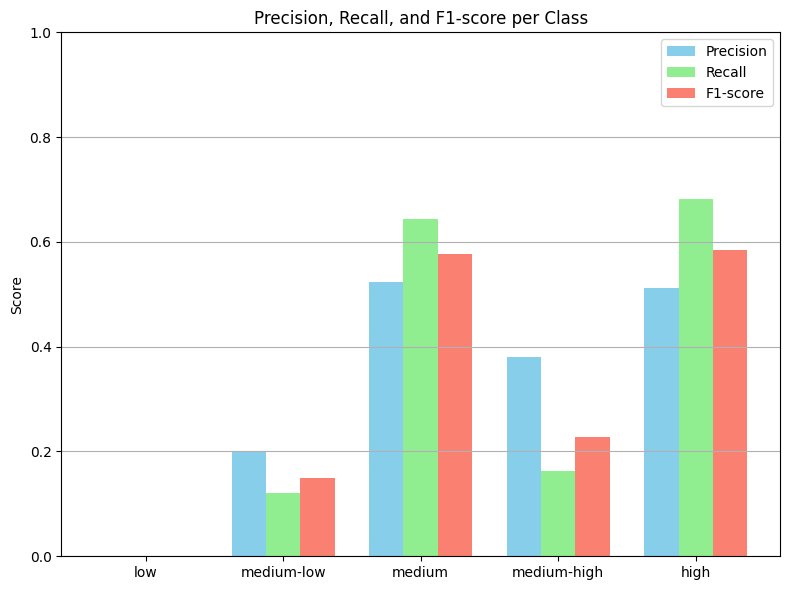

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

# precision, recall, and F1-score
precision = precision_score(y_test, y_pred, average=None, labels=[0,1,2,3,4])
recall = recall_score(y_test, y_pred, average=None, labels=[0,1,2,3,4])
f1 = f1_score(y_test, y_pred, average=None, labels=[0,1,2,3,4])

# visualization
x = np.arange(len(class_names))  # posizione centrale per ogni classe
width = 0.25  # larghezza delle barre

# create plot
plt.figure(figsize=(8, 6))
plt.bar(x - width, precision, width=width, label='Precision', color='skyblue')
plt.bar(x, recall, width=width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width=width, label='F1-score', color='salmon')

plt.xticks(x, class_names)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score per Class')
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()